In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (CLASSIFICATION SUITE)
# ==============================================================================
import os
import sys
import time
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization Engine
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Serialization & Production
import joblib

# Global Plotting & Warning Configurations
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Universal Enterprise Classification Suite imported successfully.")


✅ Universal Enterprise Classification Suite imported successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ENTERPRISE DATA INGESTION & 3-SECOND RAPID AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"❌ File not found at: {path.resolve()}")
        
    try:
        if path.suffix.lower() in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print("⚠️ UTF-8 decoding failed. Retrying with 'latin-1' encoding...")
        df = pd.read_csv(path, encoding='latin-1')
        
    print("=" * 70)
    print("📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT")
    print("=" * 70)
    print(f"File Source               : {path.name}")
    print(f"Total Observations (Rows) : {df.shape[0]:,}")
    print(f"Total Features (Columns)  : {df.shape[1]}")
    print(f"Numerical Columns         : {len(df.select_dtypes(include=['number']).columns)} cols")
    print(f"Categorical/Text Columns  : {len(df.select_dtypes(exclude=['number']).columns)} cols")
    print(f"Missing Value Cells       : {df.isnull().sum().sum():,} nulls ({df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100:.2f}%)")
    print(f"Memory Footprint in RAM   : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print("=" * 70)
    return df

df = load_and_audit_dataset("data/heart_disease/heart.csv")
display(df.head(5))


📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT
File Source               : heart.csv
Total Observations (Rows) : 920
Total Features (Columns)  : 14
Numerical Columns         : 13 cols
Categorical/Text Columns  : 1 cols
Missing Value Cells       : 1,759 nulls (13.66%)
Memory Footprint in RAM   : 0.10 MB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR (CLASSIFICATION)
# ==============================================================================
import pandas as pd
import numpy as np

def segregate_features(df, target_col, user_drop_cols=None, cardinality_threshold=0.05):
    if user_drop_cols is None:
        drop_cols = []
    else:
        drop_cols = list(user_drop_cols)
        
    cont_cols = []
    cat_cols = []
    
    candidate_cols = [c for c in df.columns if c != target_col and c not in drop_cols]
    
    for col in candidate_cols:
        col_series = df[col]
        if pd.api.types.is_numeric_dtype(col_series):
            if col_series.nunique() <= 1:
                drop_cols.append(col)
            elif col_series.nunique() <= 5:
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        elif pd.api.types.is_object_dtype(col_series) or pd.api.types.is_string_dtype(col_series):
            unique_ratio = col_series.nunique() / len(df)
            if unique_ratio > cardinality_threshold and col_series.nunique() > 50:
                drop_cols.append(col)
            else:
                cat_cols.append(col)
        else:
            cat_cols.append(col)
            
    # Guarantee uniform string type for categorical features to prevent mixed-type encoding errors
    for col in cat_cols:
        df[col] = df[col].fillna('Missing').astype(str)
        
    print("=" * 70)
    print("🔍 FEATURE SEGREGATION REPORT")
    print("=" * 70)
    print(f"Target Column          : '{target_col}'")
    print(f"Continuous Features    : {len(cont_cols)} cols -> {cont_cols}")
    print(f"Categorical Features   : {len(cat_cols)} cols -> {cat_cols}")
    print(f"Dropped ID / Artifacts : {len(drop_cols)} cols -> {drop_cols}")
    print("=" * 70)
    
    return cont_cols, cat_cols, drop_cols

cont_cols, cat_cols, drop_cols = segregate_features(
    df, 
    target_col='target', 
    user_drop_cols=[]
)


🔍 FEATURE SEGREGATION REPORT
Target Column          : 'target'
Continuous Features    : 5 cols -> ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical Features   : 8 cols -> ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Dropped ID / Artifacts : 0 cols -> []


In [4]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
import pandas as pd

def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE & PURITY REPORT")
    print("=" * 70)
    
    n_dups = df.duplicated().sum()
    if n_dups > 0:
        print(f"⚠️ FOUND {n_dups:,} EXACT DUPLICATE ROWS!")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"✅ Cleaned: {n_dups:,} duplicates removed. New Shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found. Data integrity is clean.")
    print("-" * 70)

    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    
    if len(null_cols) > 0:
        null_report = pd.DataFrame({
            "Missing Count": null_cols,
            "Percentage (%)": (null_cols / len(df) * 100).round(2),
            "Data Type": [df[col].dtype for col in null_cols.index]
        })
        print(f"🚨 FOUND {len(null_cols)} COLUMNS WITH MISSING VALUES:")
        print(null_report.to_string())
    else:
        print("✅ Zero missing values across all features. Dataset is complete.")
    print("=" * 70)
    
    return df

df = audit_and_clean_hygiene(df, drop_duplicates=True)


🧹 STEP 4: DATA HYGIENE & PURITY REPORT
⚠️ FOUND 2 EXACT DUPLICATE ROWS!
✅ Cleaned: 2 duplicates removed. New Shape: (918, 14)
----------------------------------------------------------------------
🚨 FOUND 4 COLUMNS WITH MISSING VALUES:
          Missing Count  Percentage (%) Data Type
oldpeak              62            6.75   float64
trestbps             59            6.43   float64
thalach              55            5.99   float64
chol                 29            3.16   float64


In [5]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE STRATIFIED SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def perform_stratified_split(df, target_col, drop_cols=None, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Target Safety Guard: Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col].astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("=" * 70)
    print("📦 STEP 5: STRATIFIED TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Observations      : {len(df):,}")
    print(f"Training Matrix  (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix   (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Train Class Ratio (1s)  : {y_train.mean()*100:.2f}% Positive")
    print(f"Test Class Ratio  (1s)  : {y_test.mean()*100:.2f}% Positive (Perfect Stratification!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_tr, X_te, y_tr, y_te = perform_stratified_split(
    df, 
    target_col='target', 
    drop_cols=drop_cols
)


📦 STEP 5: STRATIFIED TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Observations      : 918
Training Matrix  (X_tr) : 734 rows × 13 features (80%)
Testing Matrix   (X_te) : 184 rows × 13 features (20%)
Train Class Ratio (1s)  : 55.31% Positive
Test Class Ratio  (1s)  : 55.43% Positive (Perfect Stratification!)


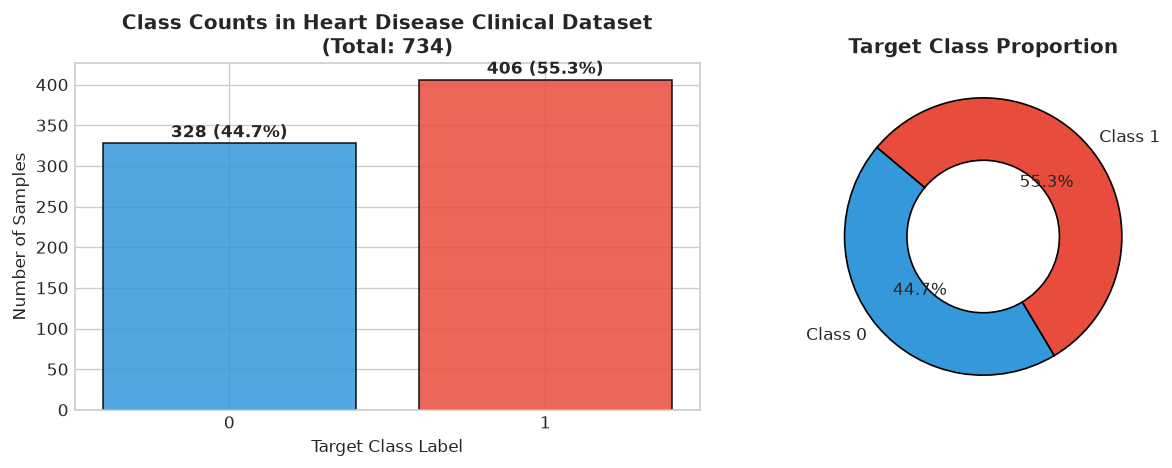

In [6]:
# ==============================================================================
# 🌐 STEP 6: TARGET CLASS BALANCE & IMBALANCE PROFILER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def profile_target_classes(y_train, dataset_name="Heart Disease Clinical Dataset"):
    counts = y_train.value_counts().sort_index()
    ratios = (y_train.value_counts(normalize=True) * 100).sort_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    colors = ['#3498db', '#e74c3c']
    axes[0].bar([str(c) for c in counts.index], counts.values, color=colors, edgecolor='black', alpha=0.85)
    axes[0].set_title(f"Class Counts in {dataset_name}\n(Total: {len(y_train):,})", fontweight='bold')
    axes[0].set_xlabel("Target Class Label")
    axes[0].set_ylabel("Number of Samples")
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + len(y_train)*0.01, f"{v:,} ({ratios.values[i]:.1f}%)", ha='center', fontweight='bold')
        
    axes[1].pie(
        ratios.values, 
        labels=[f"Class {c}" for c in ratios.index], 
        autopct='%1.1f%%', 
        colors=colors,
        startangle=140,
        wedgeprops=dict(width=0.45, edgecolor='black')
    )
    axes[1].set_title("Target Class Proportion", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

profile_target_classes(y_tr)


In [7]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="Missing"):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=cat_impute_value)),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, continuous_features),
        ('cat', cat_pipeline, categorical_features)
    ])
    
    return preprocessor

def execute_safe_preprocessing(preprocessor, X_train, X_test, continuous_features, categorical_features):
    X_tr_proc = preprocessor.fit_transform(X_train)
    X_te_proc = preprocessor.transform(X_test)
    
    if len(categorical_features) > 0:
        cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_features))
    else:
        cat_encoded_names = []
        
    all_feature_names = continuous_features + cat_encoded_names
    
    print("=" * 70)
    print("⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)")
    print("=" * 70)
    print(f"Continuous Features Processed   : {len(continuous_features)} cols")
    print(f"Categorical Features Processed  : {len(categorical_features)} cols")
    print(f"One-Hot Dummy Features Created  : {len(cat_encoded_names)} cols")
    print(f"Total Model Input Dimensions    : {X_tr_proc.shape[1]} features")
    print(f"X_train Processed Shape         : {X_tr_proc.shape}")
    print(f"X_test Processed Shape          : {X_te_proc.shape}")
    print("=" * 70)
    
    return X_tr_proc, X_te_proc, all_feature_names

continuous_features, categorical_features = cont_cols, cat_cols
X_train, X_test = X_tr, X_te
preprocessor = build_universal_preprocessor(continuous_features, categorical_features)
X_train_final, X_test_final, all_names = execute_safe_preprocessing(
    preprocessor, X_train, X_test, continuous_features, categorical_features
)


⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)
Continuous Features Processed   : 5 cols
Categorical Features Processed  : 8 cols
One-Hot Dummy Features Created  : 23 cols
Total Model Input Dimensions    : 28 features
X_train Processed Shape         : (734, 28)
X_test Processed Shape          : (184, 28)


In [8]:
# ==============================================================================
# 🏆 STEP 8: SGDCLASSIFIER HYPERPARAMETER TUNING VIA GRIDSEARCHCV
# ==============================================================================
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Search Grid for SGD Classifier (Supporting Probabilities)
param_grid = {
    'loss': ['log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate': ['adaptive', 'optimal'],
    'eta0': [0.01, 0.05],
    'class_weight': ['balanced', None]
}

# 2. Stratified 5-Fold Cross-Validation on Training Data ONLY
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sgd_base = SGDClassifier(
    max_iter=5000, 
    tol=1e-3, 
    early_stopping=True, 
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=sgd_base,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train_final, y_tr)

best_sgd = grid_search.best_estimator_
best_params = grid_search.best_params_

print("=" * 70)
print("🏆 STEP 8: SGDCLASSIFIER HYPERPARAMETER TUNING REPORT")
print("=" * 70)
print(f"Optimal Loss Function        : '{best_params['loss']}' (Supports predict_proba)")
print(f"Optimal Penalty Type         : '{best_params['penalty']}'")
print(f"Optimal Regularization Alpha : {best_params['alpha']:.5f}")
print(f"Optimal Learning Rate Policy : '{best_params['learning_rate']}'")
print(f"Optimal Initial Step (eta0)  : {best_params['eta0']}")
print(f"Optimal Class Weight         : {best_params['class_weight']}")
print(f"Best 5-Fold Cross-Val ROC-AUC: {grid_search.best_score_ * 100:.2f}%")
print(f"Epochs to Converge           : {best_sgd.n_iter_} iterations")
print(f"Model Intercept              : {best_sgd.intercept_[0]:.4f}")
print("=" * 70)


🏆 STEP 8: SGDCLASSIFIER HYPERPARAMETER TUNING REPORT
Optimal Loss Function        : 'modified_huber' (Supports predict_proba)
Optimal Penalty Type         : 'l1'
Optimal Regularization Alpha : 0.01000
Optimal Learning Rate Policy : 'adaptive'
Optimal Initial Step (eta0)  : 0.05
Optimal Class Weight         : None
Best 5-Fold Cross-Val ROC-AUC: 89.02%
Epochs to Converge           : 48 iterations
Model Intercept              : -1.0907


In [9]:
# ==============================================================================
# ⚔️ STEP 9: THE QUAD CLASSIFICATION BATTLE SHOWDOWN
# ==============================================================================
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import time

# 1. Initialize 4 Linear Contenders
models = {
    'Logistic Regression (L-BFGS)': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC (LibLinear)':       LinearSVC(dual=False, random_state=42),
    'Perceptron':                   Perceptron(random_state=42),
    'SGD Classifier (Iterative)':   best_sgd
}

rows = []
for name, mod in models.items():
    t0 = time.time()
    mod.fit(X_train_final, y_tr)
    fit_time = (time.time() - t0) * 1000  # in milliseconds
    
    y_pred = mod.predict(X_test_final)
    
    # Score for ROC-AUC
    if hasattr(mod, "predict_proba"):
        y_score = mod.predict_proba(X_test_final)[:, 1]
    elif hasattr(mod, "decision_function"):
        y_score = mod.decision_function(X_test_final)
    else:
        y_score = y_pred
        
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_score)
    
    rows.append({
        'Model Name': name,
        'Train Time': f"{fit_time:.2f} ms",
        'Accuracy': f"{acc*100:.2f}%",
        'Precision': f"{prec*100:.2f}%",
        'Recall': f"{rec*100:.2f}%",
        'F1-Score': f"{f1*100:.2f}%",
        'ROC-AUC': f"{auc*100:.2f}%"
    })

battle_df = pd.DataFrame(rows)

print("=" * 95)
print("🏆 THE QUAD CLASSIFICATION BATTLE SHOWDOWN")
print("=" * 95)
print(battle_df.to_string(index=False))
print("=" * 95)


🏆 THE QUAD CLASSIFICATION BATTLE SHOWDOWN
                  Model Name Train Time Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression (L-BFGS)   25.47 ms   85.33%    84.40% 90.20%   87.20%  92.49%
      Linear SVC (LibLinear)    2.36 ms   85.33%    84.40% 90.20%   87.20%  92.26%
                  Perceptron    1.86 ms   80.43%    85.11% 78.43%   81.63%  90.44%
  SGD Classifier (Iterative)   42.59 ms   83.70%    82.73% 89.22%   85.85%  92.13%


📊 DETAILED CLASSIFICATION REPORT (SGD CLASSIFIER):
              precision    recall  f1-score   support

           0     0.8514    0.7683    0.8077        82
           1     0.8273    0.8922    0.8585       102

    accuracy                         0.8370       184
   macro avg     0.8393    0.8302    0.8331       184
weighted avg     0.8380    0.8370    0.8359       184



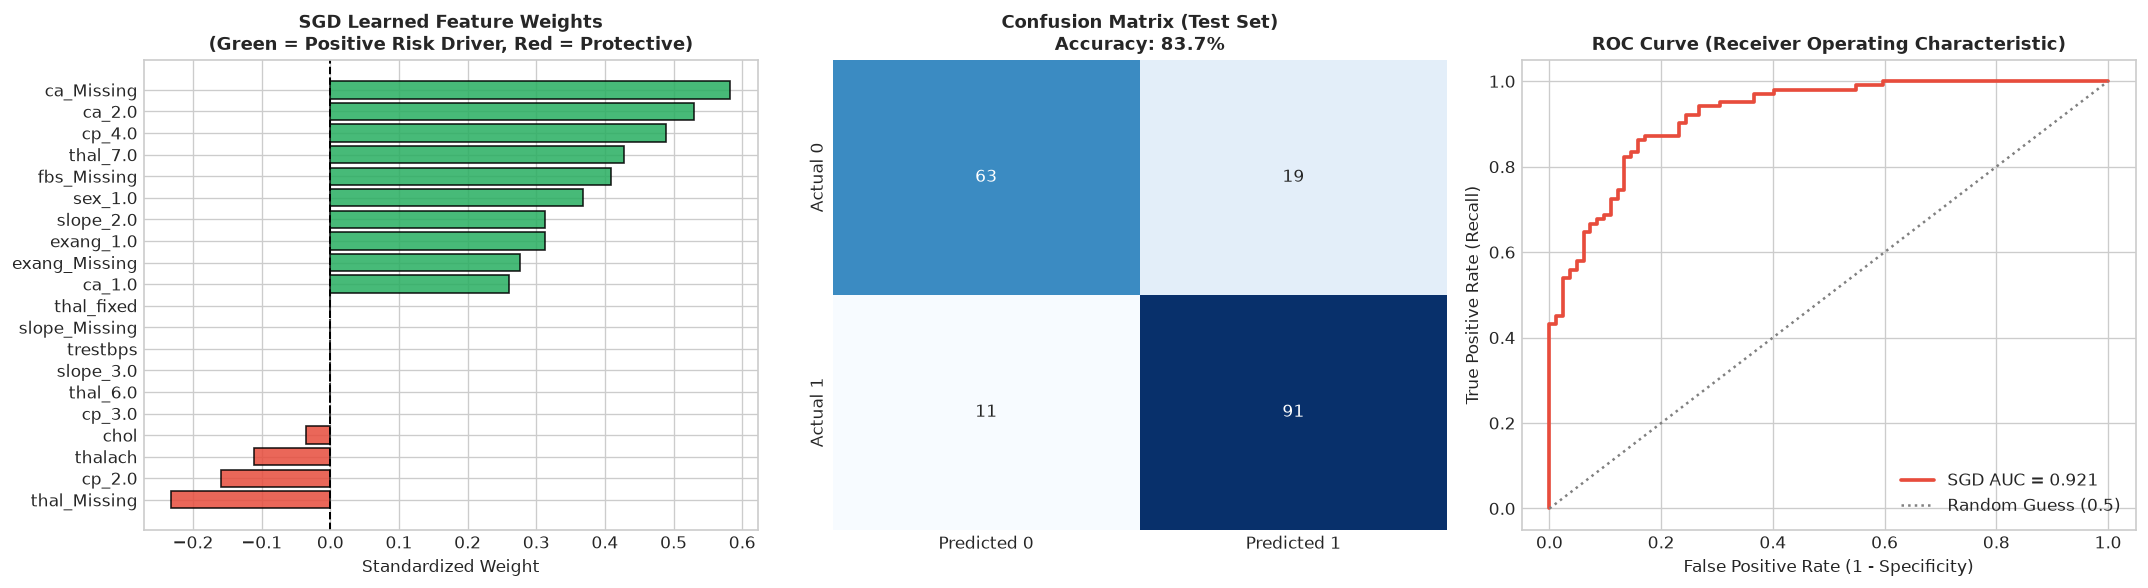

In [10]:
# ==============================================================================
# 📊 STEP 10: SGD FEATURE IMPORTANCE & CLASSIFICATION DIAGNOSTICS DASHBOARD
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Feature Importance (Horizontal Bar Chart)
weights_df = pd.DataFrame({
    'Feature': all_names,
    'Weight': best_sgd.coef_[0]
}).sort_values(by='Weight', ascending=True)

if len(weights_df) > 20:
    top_neg = weights_df.head(10)
    top_pos = weights_df.tail(10)
    plot_df = pd.concat([top_neg, top_pos])
else:
    plot_df = weights_df

colors = ['#27ae60' if w > 0 else '#e74c3c' for w in plot_df['Weight']]
axes[0].barh(plot_df['Feature'], plot_df['Weight'], color=colors, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[0].set_title(f"SGD Learned Feature Weights\n(Green = Positive Risk Driver, Red = Protective)", fontweight='bold', fontsize=11)
axes[0].set_xlabel("Standardized Weight")

# 2. Confusion Matrix Heatmap
y_pred_sgd = best_sgd.predict(X_test_final)
cm = confusion_matrix(y_te, y_pred_sgd)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title(f"Confusion Matrix (Test Set)\nAccuracy: {accuracy_score(y_te, y_pred_sgd)*100:.1f}%", fontweight='bold', fontsize=11)

# 3. ROC Curve
if hasattr(best_sgd, "predict_proba"):
    y_prob_sgd = best_sgd.predict_proba(X_test_final)[:, 1]
else:
    y_prob_sgd = best_sgd.decision_function(X_test_final)

fpr, tpr, _ = roc_curve(y_te, y_prob_sgd)
auc_val = roc_auc_score(y_te, y_prob_sgd)

axes[2].plot(fpr, tpr, color='#e74c3c', linewidth=2.2, label=f"SGD AUC = {auc_val:.3f}")
axes[2].plot([0, 1], [0, 1], color='gray', linestyle=':', label="Random Guess (0.5)")
axes[2].set_title("ROC Curve (Receiver Operating Characteristic)", fontweight='bold', fontsize=11)
axes[2].set_xlabel("False Positive Rate (1 - Specificity)")
axes[2].set_ylabel("True Positive Rate (Recall)")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("=" * 70)
print("📊 DETAILED CLASSIFICATION REPORT (SGD CLASSIFIER):")
print("=" * 70)
print(classification_report(y_te, y_pred_sgd, digits=4))
print("=" * 70)


In [11]:
# ==============================================================================
# 🏭 STEP 11: PRODUCTION PIPELINE SERIALIZATION & LIVE INFERENCE TEST
# ==============================================================================
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

# 1. Master Pipeline Assemble Karein
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('sgd_classifier', best_sgd)
])

# 2. Fit Strictly on Raw X_tr & Target y_tr
production_pipeline.fit(X_tr, y_tr)

# 3. Model Disk par Save Karein
model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'heart_disease_sgd_clf_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print("=" * 70)
print("🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY")
print("=" * 70)
print(f"✅ Full Production Pipeline Saved: {model_path}")
print(f"   Artifact File Size           : {model_path.stat().st_size / 1024:.2f} KB")
print("=" * 70)

# 4. Live Smoke Test: Ek Unseen Single Record par Live Inference
loaded_pipeline = joblib.load(model_path)
sample_record = X_te.iloc[0:1]

predicted_class = loaded_pipeline.predict(sample_record)[0]

if hasattr(loaded_pipeline, "predict_proba"):
    prob_score = loaded_pipeline.predict_proba(sample_record)[0, 1]
    prob_str = f"{prob_score*100:.2f}%"
else:
    prob_str = "N/A (Margin Loss)"

print("\n🧪 LIVE REAL-TIME CLASSIFICATION TEST (1 PATIENT):")
print("-" * 65)
for col in sample_record.columns[:6]:
    print(f"   • {col:<22}: {sample_record[col].values[0]}")
print("   • ...")
print("-" * 65)
print(f"   🎯 Model Predicted Class : {predicted_class} ({'POSITIVE / AT-RISK' if predicted_class == 1 else 'NEGATIVE / NORMAL'})")
print(f"   📈 Confidence / Prob     : {prob_str}")
print(f"   🏷️ Ground Truth Actual   : {y_te.iloc[0]}")
print(f"   ✅ Prediction Match      : {'CORRECT MATCH' if predicted_class == y_te.iloc[0] else 'MISMATCH'}")
print("=" * 70)


🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY
✅ Full Production Pipeline Saved: production_models/heart_disease_sgd_clf_pipeline.joblib
   Artifact File Size           : 6.69 KB

🧪 LIVE REAL-TIME CLASSIFICATION TEST (1 PATIENT):
-----------------------------------------------------------------
   • age                   : 49.0
   • sex                   : 1.0
   • cp                    : 4.0
   • trestbps              : 130.0
   • chol                  : 206.0
   • fbs                   : 0.0
   • ...
-----------------------------------------------------------------
   🎯 Model Predicted Class : 0 (NEGATIVE / NORMAL)
   📈 Confidence / Prob     : 42.44%
   🏷️ Ground Truth Actual   : 1
   ✅ Prediction Match      : MISMATCH
